# Load the Data

In [45]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os, inspect

data_folder = "./results/"
 
def get_csvs_recursive(dir_name):
    """
    recursively finds all .csv files below a specified directory and returns them as 
    a list of file paths. Usefull for combining results from multiple simulation runs.
    """
    dir_list = os.listdir(dir_name)
    cur_fnames = []
    
    for item_name in dir_list:
        # if file
        if ".csv" in item_name:
            cur_fnames += [dir_name+"/"+item_name]
        # if folder
        elif "." not in item_name:
            sub_fnames = get_csvs_recursive(dir_name+"/"+item_name)
            cur_fnames += sub_fnames
    return cur_fnames
            
    
data_fnames = get_csvs_recursive(data_folder)

# combine all files into a longform dataframe for plotting
sim_dfs= []
for filename in data_fnames:
    cur_df = pd.read_csv(filename)
    sim_dfs += [cur_df]
        
phrase_df = pd.concat(sim_dfs).reset_index(drop=True)

phrase_df["lm_config"] = "char: "+phrase_df["char_lm_type"]+", word: "+phrase_df["word_lm_type"]

print("Unique Paramater Configurations:")
phrase_df.filter(items=["user_id", "char_lm_type", "word_lm_type", "phrase_set"]).drop_duplicates()

Unique Paramater Configurations:


,user_id,char_lm_type,word_lm_type,phrase_set
0,A,tiny,tiny,watch
122,A,medium,medium,watch
244,A,dec19,dec19,watch


# Plot the Data

Text(0.5, 0.98, 'Effects of Language Model Compression')

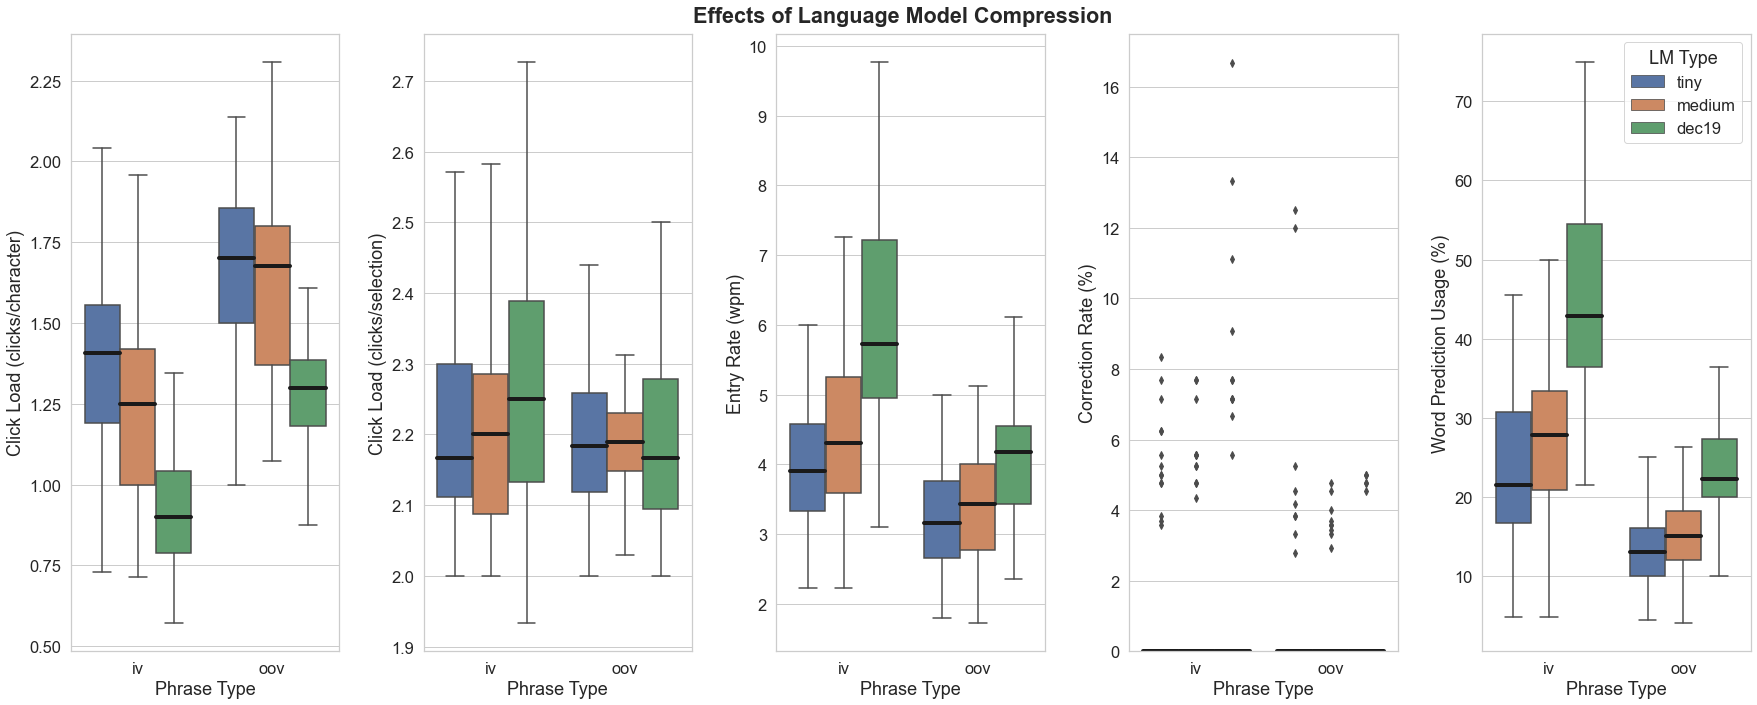

In [44]:
# setup and format a double figure for the plots
fig, axes = plt.subplots(1, 5, figsize=(25, 10))
fig.tight_layout(pad=2)
sns.set_context("paper")
sns.set(font_scale=1.5)
sns.set_style("whitegrid")

sns.set_context("paper")
sns.set(font_scale=1.5)
sns.set_style("whitegrid")

# plot the data as boxplots
plot_df = phrase_df

dep_vars = ["Click Load (clicks/character)", "Click Load (clicks/selection)", "Entry Rate (wpm)", "Correction Rate (%)", "Word Prediction Usage (%)"]
for col_num, dep_var in enumerate(dep_vars):
    cur_ax = axes[col_num]
    hue_order = ['tiny', 'medium', 'dec19']
    
    sns.boxplot(data=plot_df, x="Phrase Type", y=dep_var,
                hue="word_lm_type", hue_order=hue_order, order=["iv", "oov"], 
                showfliers=dep_var == "Correction Rate (%)", 
                medianprops={"color": "k", "linewidth": 4}, ax=cur_ax)
    
    if dep_var == "Correction Rate (%)":
        cur_ymax = cur_ax.get_ylim()[1]
        cur_ax.set_ylim(0, max(10, cur_ymax))
            
    if col_num != 4:
        cur_ax.get_legend().remove()
    else:
        cur_ax.legend(loc=1)
        cur_ax.get_legend().set_title("LM Type")
fig.suptitle("Effects of Language Model Compression", fontsize="large", fontweight="bold")
